In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import cv2
from sklearn.model_selection import train_test_split
import shutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# EDA

In [2]:
ANNOTATIONS_DIR = '/kaggle/input/maskfacedataset/annotations'

def extract_bbox_info(xml_file_path):
    """Trích xuất thông tin bounding box và nhãn từ một tệp XML (Pascal VOC)."""
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    
    # Lấy tên ảnh và kích thước ảnh
    image_name = root.find('filename').text
    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)
    
    records = []
    
    # Duyệt qua tất cả các đối tượng (object) trong ảnh
    for obj in root.findall('object'):
        label = obj.find('name').text # with_mask hoặc without_mask
        bbox = obj.find('bndbox')
        
        # Lấy tọa độ
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        records.append({
            'image_name': image_name,
            'img_width': img_width,
            'img_height': img_height,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax,
            'label': label
        })
        
    return records

In [3]:
# 1. Quét và Xử lý tất cả các tệp XML
all_records = []
xml_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.xml')]

print(f"Bắt đầu xử lý {len(xml_files)} tệp XML...")

for xml_file in xml_files:
    xml_path = os.path.join(ANNOTATIONS_DIR, xml_file)
    try:
        records = extract_bbox_info(xml_path)
        all_records.extend(records)
    except Exception as e:
        print(f"Lỗi khi xử lý tệp {xml_file}: {e}")

# 2. Tạo DataFrame
df = pd.DataFrame(all_records)

print(f"Tổng số bounding box (khuôn mặt) được chú thích: {len(df)}")
print("\n--- Cấu trúc DataFrame đã trích xuất ---")
df.head()

Bắt đầu xử lý 853 tệp XML...
Tổng số bounding box (khuôn mặt) được chú thích: 4072

--- Cấu trúc DataFrame đã trích xuất ---


,image_name,img_width,img_height,xmin,ymin,xmax,ymax,label
0,maksssksksss737.png,400,226,28,55,46,71,with_mask
1,maksssksksss737.png,400,226,98,62,111,78,with_mask
2,maksssksksss737.png,400,226,159,50,193,90,mask_weared_incorrect
3,maksssksksss737.png,400,226,293,59,313,80,with_mask
4,maksssksksss737.png,400,226,352,51,372,72,with_mask


In [4]:
print(f"Tổng số ảnh duy nhất: {df['image_name'].nunique()}")
print(f"Số lớp: {df['label'].nunique()}")

Tổng số ảnh duy nhất: 853
Số lớp: 3


In [5]:
# Lấy DataFrame chứa kích thước ảnh duy nhất
image_dims = df[['image_name', 'img_width', 'img_height']].drop_duplicates()

print("\n--- Thống kê Kích thước Ảnh ---")
image_dims[['img_width', 'img_height']].describe()


--- Thống kê Kích thước Ảnh ---


,img_width,img_height
count,853.000000,853.000000
mean,370.589683,309.289566
std,56.224049,74.474840
min,193.000000,156.000000
25%,301.000000,254.000000
50%,400.000000,280.000000
75%,400.000000,400.000000
max,600.000000,600.000000


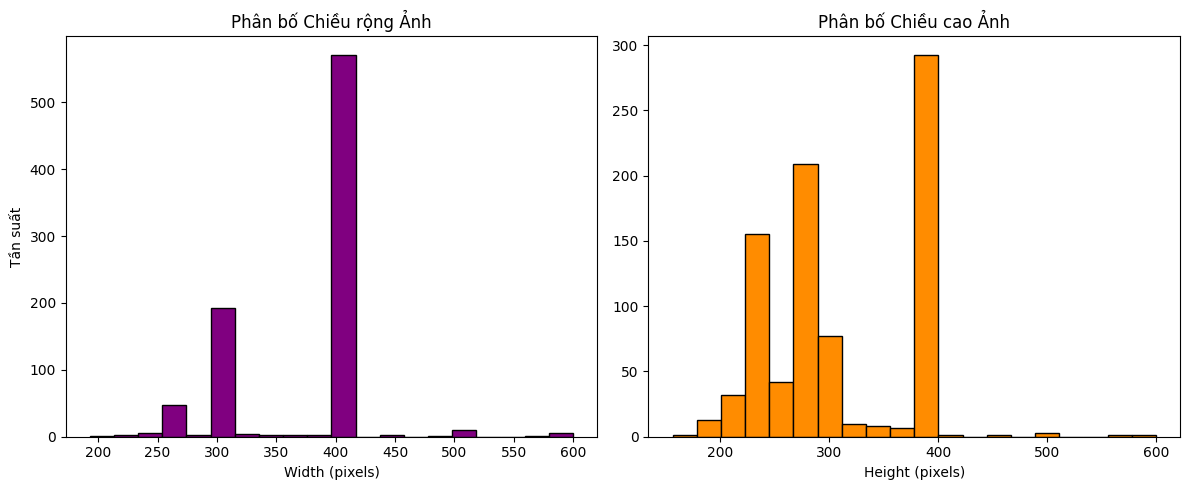

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(image_dims['img_width'], bins=20, color='purple', edgecolor='black')
plt.title('Phân bố Chiều rộng Ảnh')
plt.xlabel('Width (pixels)')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
plt.hist(image_dims['img_height'], bins=20, color='darkorange', edgecolor='black')
plt.title('Phân bố Chiều cao Ảnh')
plt.xlabel('Height (pixels)')

plt.tight_layout()
plt.show()

## Số lượng label

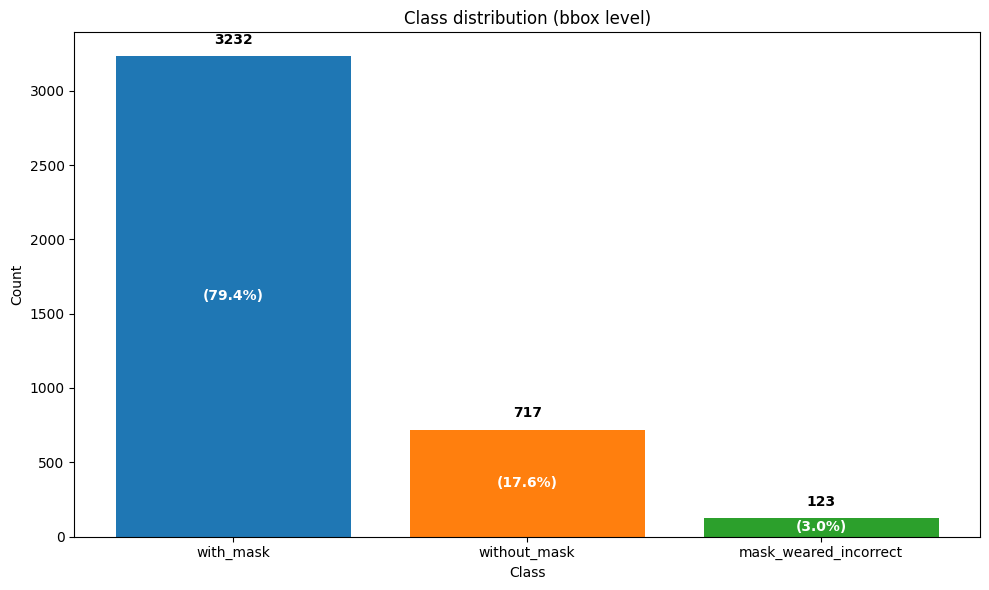

In [7]:
# Đếm số lượng theo class
cls_counts = df['label'].value_counts()      # Series: index = nhãn, values = số lượng
labels = cls_counts.index.tolist()
counts = cls_counts.values.tolist()

# Tổng số mẫu để tính phần trăm
total_samples = sum(counts)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Vẽ biểu đồ trên một figure
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color=colors)

plt.title("Class distribution (bbox level)")
plt.xlabel("Class")
plt.ylabel("Count")

# Thêm số lượng và phần trăm lên mỗi cột
for bar in bars:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2.0

    # Hiển thị số lượng ở phía trên cột
    plt.text(
        x, height + max(counts) * 0.02,  # tăng một chút so với đỉnh cột
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

    # Hiển thị phần trăm ở giữa cột
    percentage = (height / total_samples) * 100 if total_samples > 0 else 0
    plt.text(
        x, height * 0.5,
        f'({percentage:.1f}%)',
        ha='center', va='center',
        fontsize=10, color='white', fontweight='bold'
    )

plt.tight_layout()
plt.show()


## Phân tích Kích thước Bounding Box


--- Thống kê Tỷ lệ Khung hình Bounding Box ---
count    4072.000000
mean        0.914403
std         0.177868
min         0.315789
25%         0.818182
50%         0.909091
75%         1.000000
max         2.510204
Name: aspect_ratio, dtype: float64


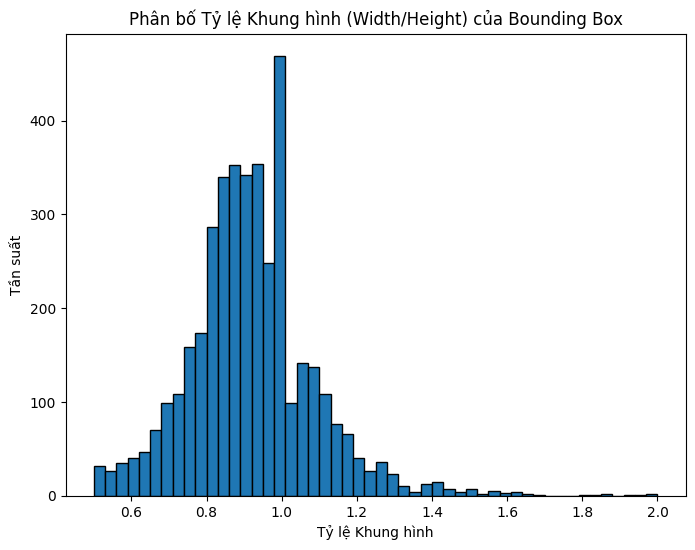

In [8]:
# Tính chiều rộng và chiều cao của Bounding Box
df['bbox_width'] = df['xmax'] - df['xmin']
df['bbox_height'] = df['ymax'] - df['ymin']

# Tính Tỷ lệ Khung hình (Aspect Ratio)
df['aspect_ratio'] = df['bbox_width'] / df['bbox_height']

print("\n--- Thống kê Tỷ lệ Khung hình Bounding Box ---")
print(df['aspect_ratio'].describe())

plt.figure(figsize=(8, 6))
plt.hist(df['aspect_ratio'], bins=50, range=(0.5, 2.0), edgecolor='black')
plt.title('Phân bố Tỷ lệ Khung hình (Width/Height) của Bounding Box')
plt.xlabel('Tỷ lệ Khung hình')
plt.ylabel('Tần suất')
plt.show()

## Số lượng Bounding Box trên mỗi Ảnh


--- Thống kê Số lượng Bounding Box trên mỗi ảnh ---
count    853.000000
mean       4.773740
std        7.394114
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      115.000000
dtype: float64


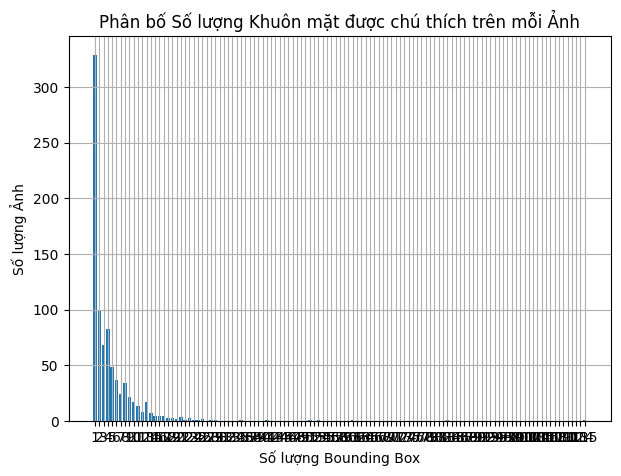

In [9]:
# 4.1. Số lượng Bounding Box (người) trên mỗi ảnh
bboxes_per_image = df.groupby('image_name').size()

print("\n--- Thống kê Số lượng Bounding Box trên mỗi ảnh ---")
print(bboxes_per_image.describe())

plt.figure(figsize=(7, 5))
bboxes_per_image.hist(bins=range(1, bboxes_per_image.max() + 2), align='left', rwidth=0.8)
plt.title('Phân bố Số lượng Khuôn mặt được chú thích trên mỗi Ảnh')
plt.xlabel('Số lượng Bounding Box')
plt.ylabel('Số lượng Ảnh')
plt.xticks(range(1, bboxes_per_image.max() + 1))
# plt.grid(axis='y', linestyle='--')
plt.show()

## Trực quan hóa Dữ liệu

In [10]:
IMAGE_DIR = '/kaggle/input/maskfacedataset/images'

# --- Cấu hình ---
IMAGE_DIR = '/kaggle/input/maskfacedataset/images'
TARGET_CLASSES = ['with_mask', 'without_mask', 'mask_weared_incorrect']
SAMPLES_PER_CLASS = 5           # số ảnh muốn hiển thị mỗi lớp
ONLY_SHOW_TARGET_CLASS_BBOX = True  # True: chỉ vẽ bbox thuộc lớp đang xét. False: vẽ tất cả bbox.


# --- Hàm vẽ bbox ---
def draw_bbox(image_path, annotations, only_target_class=None):
    """
    Vẽ Bounding Box lên ảnh.
    - Xanh lá: with_mask
    - Đỏ: without_mask
    - Vàng: mask_weared_incorrect
    
    only_target_class: nếu truyền chuỗi tên lớp → chỉ vẽ bbox của lớp đó
                       nếu None → vẽ tất cả bbox
    """
    # 1. Đọc ảnh
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Không thể đọc ảnh tại: {image_path}")

    # OpenCV đọc BGR → chuyển sang RGB để hiển thị đúng màu trong matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Vẽ bbox
    for _, row in annotations.iterrows():
        label = row['label']
        if only_target_class is not None and label != only_target_class:
            continue  # bỏ qua bbox không thuộc lớp đang xét

        # Lấy tọa độ bbox (đảm bảo là int)
        xmin, ymin = int(row['xmin']), int(row['ymin'])
        xmax, ymax = int(row['xmax']), int(row['xmax']) if 'ymax' not in row else int(row['ymax'])

        # Màu theo nhãn (RGB)
        if label == 'with_mask':
            color = (0, 255, 0)      # Xanh lá
        elif label == 'without_mask':
            color = (255, 0, 0)      # Đỏ
        elif label == 'mask_weared_incorrect':
            color = (255, 255, 0)    # Vàng
        else:
            color = (255, 255, 255)  # Trắng (nhãn khác)

        thickness = 2
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, thickness)

        # Vẽ nền mờ cho nhãn để dễ đọc (tuỳ chọn)
        # cv2.rectangle(img, (xmin, ymin - 22), (xmin + 8*len(label), ymin), color, -1)

        # Vẽ label
        cv2.putText(img, label, (xmin, max(0, ymin - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
    return img


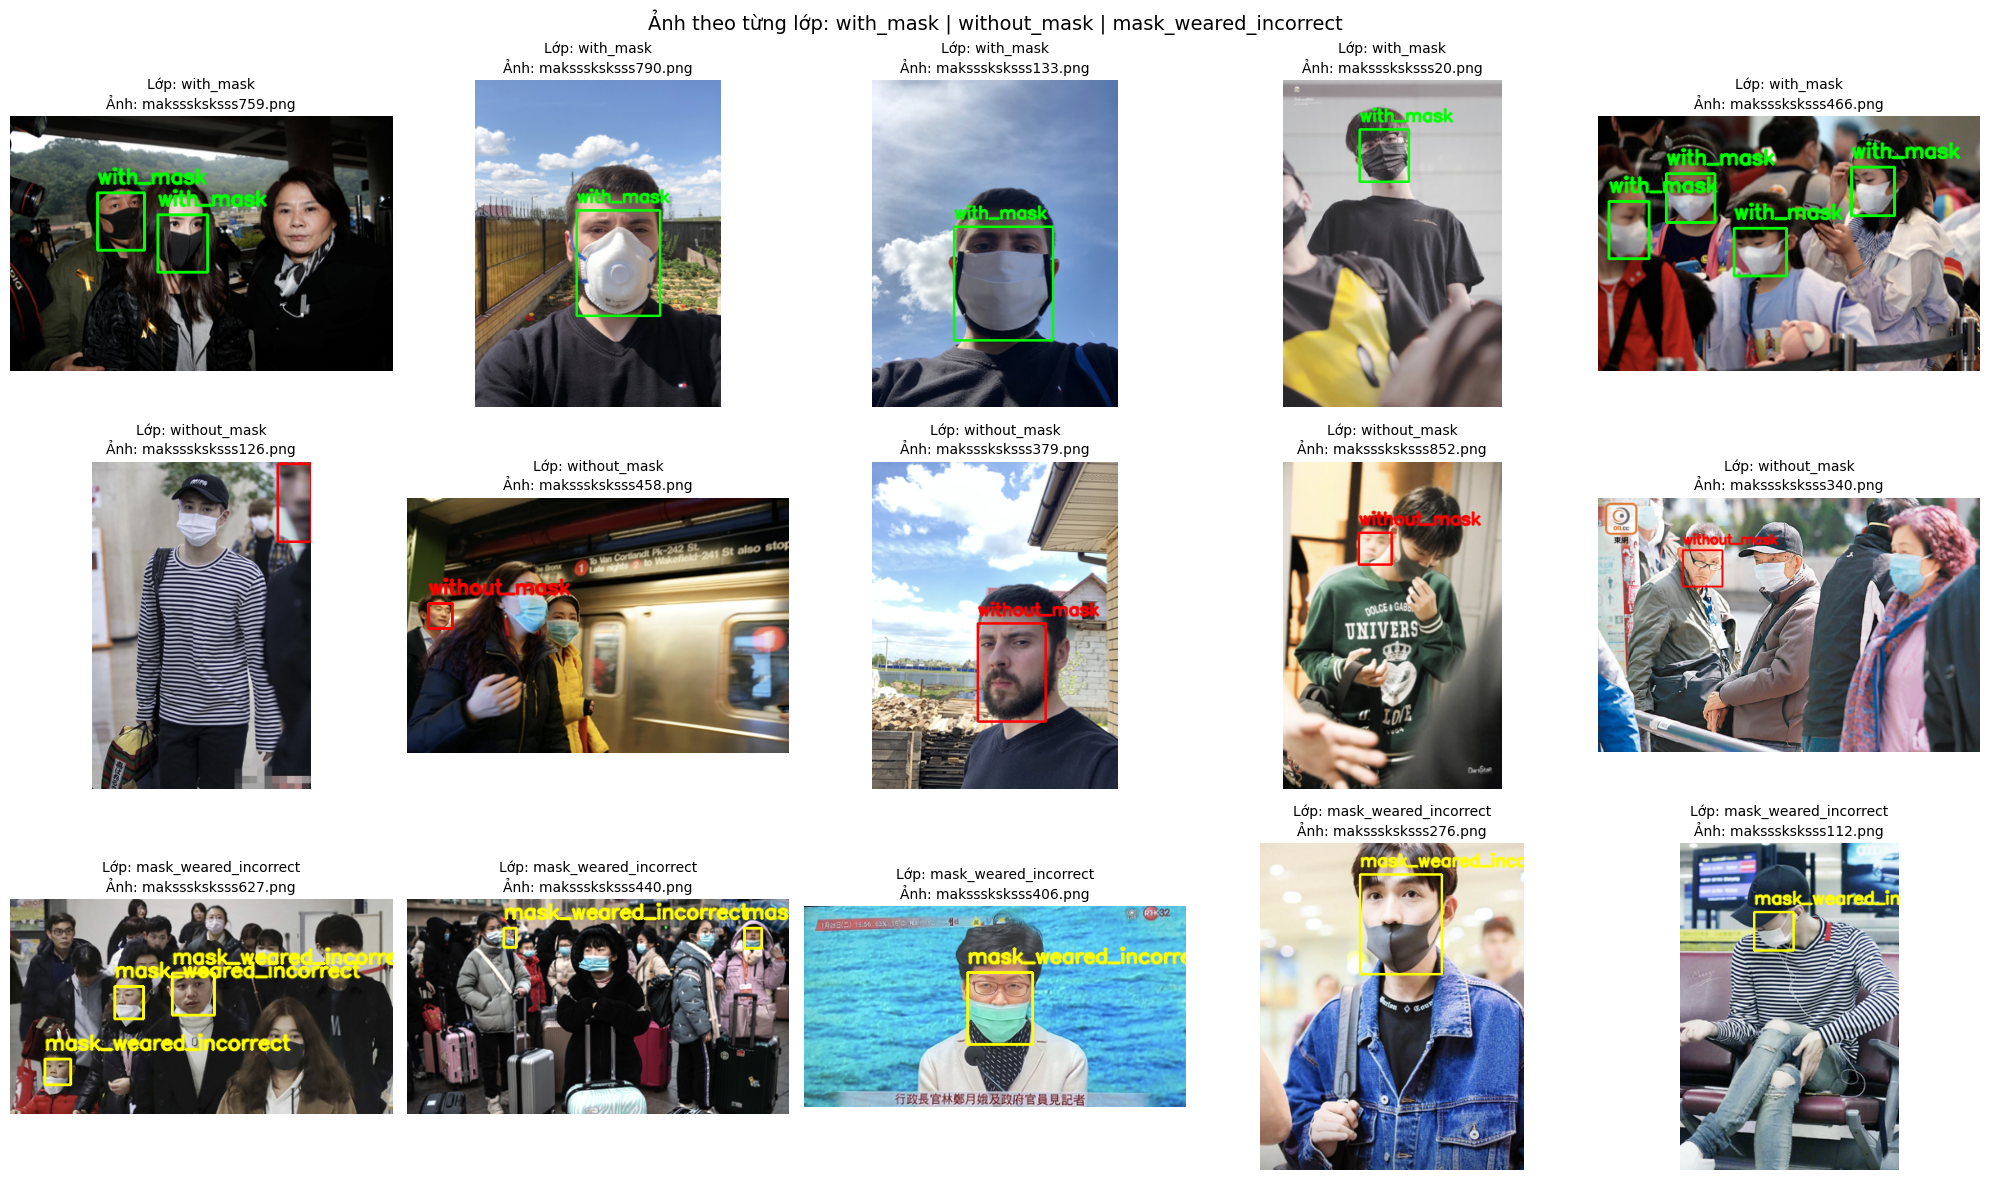

In [11]:

 # --- Lấy danh sách ảnh theo từng lớp ---
# Mỗi lớp lấy danh sách các ảnh (image_name) có xuất hiện lớp đó
class_to_images = {}
for cls in TARGET_CLASSES:
    # các ảnh có ít nhất một bbox thuộc lớp cls
    image_names = df.loc[df['label'] == cls, 'image_name'].unique().tolist()
    random.shuffle(image_names)
    class_to_images[cls] = image_names[:SAMPLES_PER_CLASS]

# --- Vẽ lưới: mỗi hàng một lớp ---
rows = len(TARGET_CLASSES)
cols = max(len(v) for v in class_to_images.values()) if rows > 0 else 0
cols = max(cols, 1)

plt.figure(figsize=(4*cols, 4*rows))

for r, cls in enumerate(TARGET_CLASSES):
    sample_images = class_to_images.get(cls, [])
    for c in range(cols):
        idx_subplot = r * cols + c + 1
        plt.subplot(rows, cols, idx_subplot)
        
        if c < len(sample_images):
            img_name = sample_images[c]
            image_path = os.path.join(IMAGE_DIR, img_name)

            if os.path.exists(image_path):
                # annotations của ảnh này (có thể là toàn bộ hoặc chỉ lọc theo cls)
                if ONLY_SHOW_TARGET_CLASS_BBOX:
                    ann = df[(df['image_name'] == img_name) & (df['label'] == cls)]
                    # Nếu ảnh không có bbox thuộc lớp đang xét (hiếm khi xảy ra do chọn trước),
                    # ta vẫn đọc tất cả bbox để hiển thị thông tin đầy đủ
                    if ann.empty:
                        ann = df[df['image_name'] == img_name]
                else:
                    ann = df[df['image_name'] == img_name]

                try:
                    img_with_boxes = draw_bbox(image_path, ann,
                                               only_target_class=(cls if ONLY_SHOW_TARGET_CLASS_BBOX else None))
                    plt.imshow(img_with_boxes)
                    plt.title(f'Lớp: {cls}\nẢnh: {img_name}', fontsize=10)
                    plt.axis('off')
                except Exception as e:
                    plt.text(0.5, 0.5, f"Lỗi xử lý ảnh:\n{e}", ha='center', va='center')
                    plt.axis('off')
            else:
                plt.text(0.5, 0.5, f"❌ Không tìm thấy ảnh:\n{image_path}", ha='center', va='center')
                plt.axis('off')
        else:
            # Nếu không đủ ảnh cho lớp đó, để trống ô
            plt.axis('off')

plt.suptitle("Ảnh theo từng lớp: with_mask | without_mask | mask_weared_incorrect", fontsize=14)
plt.tight_layout()
plt.show()


# Preprocessing data

In [12]:
# gộp mask_weared_incorrect vào without_mask
df['label_2'] = df['label'].replace({
    'with_mask': 'with_mask',
    'without_mask': 'without_mask',
    'mask_weared_incorrect': 'without_mask'
})

CLASS_MAP = {
    'with_mask': 0,
    'without_mask': 1,          
}

print(df['label'].value_counts())
print("After merge to 2 classes:")
print(df['label_2'].value_counts())

label
with_mask                3232
without_mask              717
mask_weared_incorrect     123
Name: count, dtype: int64
After merge to 2 classes:
label_2
with_mask       3232
without_mask     840
Name: count, dtype: int64


In [13]:
def convert_bbox_to_yolo(size, box):
    """size: (width, height), box: (xmin, ymin, xmax, ymax)"""
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    
    x = (box[0] + box[2]) / 2.0
    y = (box[1] + box[3]) / 2.0
    w = box[2] - box[0]
    h = box[3] - box[1]
    
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    
    return (x, y, w, h)

In [14]:
def process_xml_file(xml_path, output_txt_path, class_map):
    # ... (Nội dung hàm giữ nguyên như bạn đã cung cấp)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)
    img_size = (img_width, img_height)
    
    yolo_annotations = []
    
    for obj in root.findall('object'):
        label_name = obj.find('name').text
        
        # Lấy ID lớp đã gộp
        class_id = class_map.get(label_name)
        
        # Lỗi tiềm ẩn: Nếu nhãn gốc không nằm trong CLASS_MAP, class_id sẽ là None
        if class_id is None:
             # Kiểm tra xem đây có phải là nhãn gốc (mask_weared_incorrect)
             if label_name in CLASS_MAP: continue # Nếu là nhãn gốc nhưng mapping là None
             else: continue # Nhãn không xác định
            
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        yolo_box = convert_bbox_to_yolo(img_size, (xmin, ymin, xmax, ymax))
        
        yolo_annotations.append(f"{class_id} {yolo_box[0]:.6f} {yolo_box[1]:.6f} {yolo_box[2]:.6f} {yolo_box[3]:.6f}")

    if yolo_annotations:
        with open(output_txt_path, 'w') as f:
            f.write('\n'.join(yolo_annotations) + '\n')
        return True
    return False

In [15]:
YOLO_OUTPUT_DIR = 'yolo_data_2classes'
os.makedirs(YOLO_OUTPUT_DIR, exist_ok=True)

In [16]:
labels_dir = os.path.join(YOLO_OUTPUT_DIR, 'labels')
images_dir = os.path.join(YOLO_OUTPUT_DIR, 'images')
os.makedirs(os.path.join(labels_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(labels_dir, 'val'), exist_ok=True)
os.makedirs(os.path.join(images_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(images_dir, 'val'), exist_ok=True)
os.makedirs(os.path.join(labels_dir, 'test'), exist_ok=True)
os.makedirs(os.path.join(images_dir, 'test'), exist_ok=True)

In [17]:
# 2. Xử lý và lưu các file TXT
xml_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.xml')]
image_names_generated = [] # Dùng biến mới để theo dõi ảnh đã tạo file nhãn thành công

print(f"Bắt đầu xử lý {len(xml_files)} tệp XML và tạo file nhãn TXT tạm thời...")

for xml_file in xml_files:
    base_name = os.path.splitext(xml_file)[0]
    xml_path = os.path.join(ANNOTATIONS_DIR, xml_file)
    output_txt_path = os.path.join(labels_dir, f"{base_name}.txt") # Lưu tạm vào labels_dir
    
    # GỌI HÀM VÀ CHUYỂN CLASS_MAP
    if process_xml_file(xml_path, output_txt_path, CLASS_MAP): 
        image_names_generated.append(base_name)

print(f"Đã tạo thành công file nhãn cho {len(image_names_generated)} ảnh.")

Bắt đầu xử lý 853 tệp XML và tạo file nhãn TXT tạm thời...
Đã tạo thành công file nhãn cho 832 ảnh.


# train

## Chia train/val/test

In [18]:
# Lọc df chỉ lấy các ảnh đã tạo file nhãn
df_filtered = df[df['image_name'].isin([f"{name}.png" for name in image_names_generated])] # Giả định ảnh là .png

In [19]:
# Tạo nhãn đại diện cho mỗi ảnh (mode theo bbox đã gộp)
# Dùng label_2 đã gộp
img_label_map = (
    df_filtered.groupby('image_name')['label_2']
      .agg(lambda x: x.mode().iat[0])
)
# Cần trích xuất tên ảnh không đuôi
img_names_no_ext = [os.path.splitext(name)[0] for name in img_label_map.index]
img_label_map.index = img_names_no_ext

In [20]:
# Chia tập theo stratify
train_names, temp_names = train_test_split(
    img_names_no_ext, test_size=0.2, random_state=42,
    stratify=img_label_map.loc[img_names_no_ext]
)

val_names, test_names = train_test_split(
    temp_names, test_size=0.5, random_state=42,
    stratify=img_label_map.loc[temp_names]
)

In [21]:
print(f"Số lượng Train: {len(train_names)}, Số lượng Validation: {len(val_names)}, Số lượng Test: {len(test_names)}")

Số lượng Train: 665, Số lượng Validation: 83, Số lượng Test: 84


In [22]:
for name in image_names_generated: # Lặp qua danh sách ảnh đã tạo file TXT thành công
    # Lấy đường dẫn file nhãn tạm thời
    src_label_path = os.path.join(labels_dir, f"{name}.txt") 

    # --- Xác định thư mục đích ---
    if name in train_names:
        img_dest_folder = os.path.join(images_dir, 'train')
        lbl_dest_folder = os.path.join(labels_dir, 'train')
    elif name in val_names:
        img_dest_folder = os.path.join(images_dir, 'val')
        lbl_dest_folder = os.path.join(labels_dir, 'val')
    elif name in test_names:
        img_dest_folder = os.path.join(images_dir, 'test')
        lbl_dest_folder = os.path.join(labels_dir, 'test')
    else:
        # Trường hợp này không nên xảy ra
        continue

    # --- Thực hiện sao chép/di chuyển file (Giữ nguyên logic .png/.jpg) ---
    img_dest = os.path.join(img_dest_folder, f"{name}.png")
    lbl_dest = os.path.join(lbl_dest_folder, f"{name}.txt")

    # 1. Xử lý file ảnh .png
    src_image_path = os.path.join(IMAGE_DIR, f"{name}.png") 
    if os.path.exists(src_image_path):
        shutil.copy(src_image_path, img_dest)
        shutil.move(src_label_path, lbl_dest) # Di chuyển file TXT tạm thời
    # 2. Xử lý file ảnh .jpg
    elif os.path.exists(os.path.join(IMAGE_DIR, f"{name}.jpg")):
        src_image_path = os.path.join(IMAGE_DIR, f"{name}.jpg")
        img_dest = os.path.join(img_dest_folder, f"{name}.jpg")
        shutil.copy(src_image_path, img_dest)
        shutil.move(src_label_path, lbl_dest) # Di chuyển file TXT tạm thời
    else:
        print(f"Cảnh báo: Không tìm thấy file ảnh {name}.png hoặc {name}.jpg. File nhãn bị xóa.")
        # Xóa file TXT tạm thời nếu không có ảnh đi kèm
        os.remove(src_label_path)

In [23]:
# # --- Khai báo các thư mục đích (đã có từ bước 1) ---
# # YOLO_OUTPUT_DIR = 'yolo_data_2classes'
# # labels_dir = os.path.join(YOLO_OUTPUT_DIR, 'labels')
# # images_dir = os.path.join(YOLO_OUTPUT_DIR, 'images')

# # --- Sửa lỗi Logic vòng lặp Di chuyển File ---

# for name in image_names:
#     # Bỏ qua nếu ảnh chưa có file chú thích YOLO (TXT)
#     src_label_path = os.path.join(labels_dir, f"{name}.txt") 
#     if not os.path.exists(src_label_path):
#         continue

#     # Xác định thư mục đích bằng IF/ELIF/ELSE
#     if name in train_names:
#         img_dest_folder = os.path.join(images_dir, 'train')
#         lbl_dest_folder = os.path.join(labels_dir, 'train')
        
#     elif name in val_names:
#         img_dest_folder = os.path.join(images_dir, 'val')
#         lbl_dest_folder = os.path.join(labels_dir, 'val')
        
#     elif name in test_names:
#         img_dest_folder = os.path.join(images_dir, 'test')
#         lbl_dest_folder = os.path.join(labels_dir, 'test')
    
#     else:
#         # Trường hợp hiếm, nếu tên ảnh không nằm trong bất kỳ tập nào (có thể do lỗi dữ liệu)
#         print(f"Cảnh báo: Ảnh {name} không thuộc tập Train/Val/Test. Bỏ qua.")
#         continue


#     # --- Thực hiện sao chép/di chuyển file (Giữ nguyên logic .png/.jpg) ---
    
#     # 1. Thiết lập đường dẫn đích
#     img_dest = os.path.join(img_dest_folder, f"{name}.png")
#     lbl_dest = os.path.join(lbl_dest_folder, f"{name}.txt")

#     # 2. Xử lý file ảnh .png
#     src_image_path = os.path.join(IMAGE_DIR, f"{name}.png") 
#     if os.path.exists(src_image_path):
#         shutil.copy(src_image_path, img_dest)
#         shutil.move(src_label_path, lbl_dest)
        
#     # 3. Xử lý file ảnh .jpg
#     elif os.path.exists(os.path.join(IMAGE_DIR, f"{name}.jpg")):
#         src_image_path = os.path.join(IMAGE_DIR, f"{name}.jpg")
#         img_dest = os.path.join(img_dest_folder, f"{name}.jpg")
#         shutil.copy(src_image_path, img_dest)
#         shutil.move(src_label_path, lbl_dest)
        
#     else:
#         print(f"Cảnh báo: Không tìm thấy file ảnh {name}.png hoặc {name}.jpg. Bỏ qua.")


# # Xóa các file TXT tạm thời
# [os.remove(os.path.join(labels_dir, f)) for f in os.listdir(labels_dir) if f.endswith('.txt') and os.path.isfile(os.path.join(labels_dir, f))]

# print("Hoàn thành Gộp Lớp và Chuẩn bị Dữ liệu 2 lớp cho YOLO.")

--- PHÂN BỐ SỐ LƯỢNG ẢNH THEO NHÃN MODE ---
              Train  Validation  Test
label_2                              
with_mask       579          72    73
without_mask     86          11    11

--- PHÂN BỐ TỶ LỆ (%) ẢNH THEO NHÃN MODE ---
              Train  Validation  Test
label_2                              
with_mask     87.07       86.75  86.9
without_mask  12.93       13.25  13.1


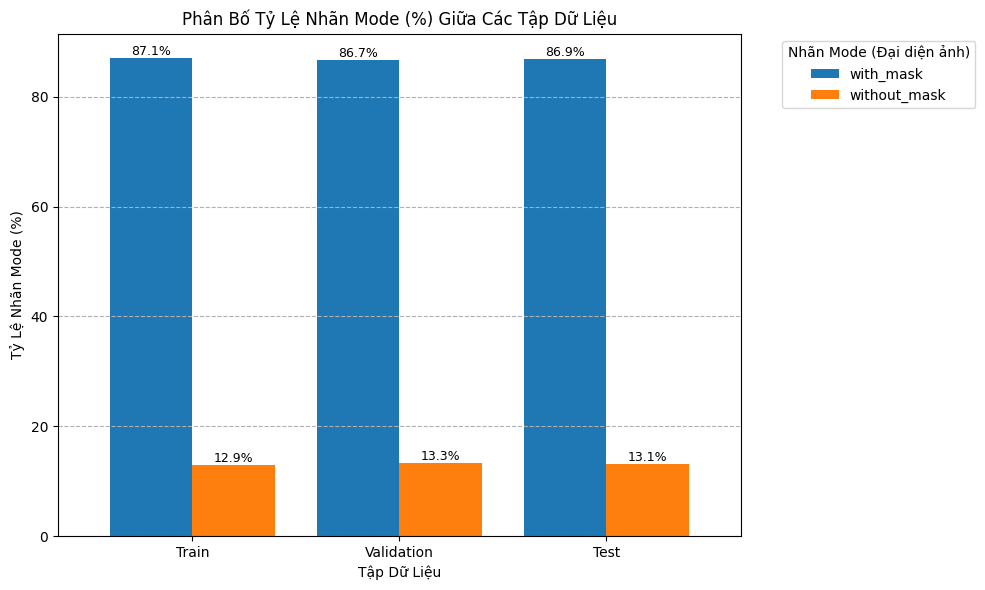

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Giả định: Các biến sau đã được định nghĩa từ các bước trước ---
# df: DataFrame chứa tất cả chú thích
# img_label_map: Series chứa nhãn mode cho mỗi ảnh (ví dụ: 'with_mask' hoặc 'without_mask')
# train_names: Danh sách tên ảnh trong tập huấn luyện
# val_names: Danh sách tên ảnh trong tập kiểm định
# test_names: Danh sách tên ảnh trong tập kiểm thử

# --- Ánh xạ nhãn sau khi gộp (nếu cần, để hiển thị rõ hơn) ---
# Nếu bạn đã gộp: 
# 'with_mask' -> 0 (with_mask), 'without_mask' và 'mask_weared_incorrect' -> 1 (not_wearing_properly)
# Giả sử img_label_map vẫn giữ tên nhãn gốc trước khi gộp
FINAL_CLASS_MAP = {
    'with_mask': 'with_mask',
    'without_mask': 'not_wearing_properly',
    'mask_weared_incorrect': 'not_wearing_properly'
}

# Áp dụng ánh xạ lớp gộp vào nhãn mode
img_label_map_final = img_label_map


# 1. Tạo DataFrame chứa nhãn mode của các tập con
train_counts = img_label_map_final.loc[train_names].value_counts().rename('Train')
val_counts = img_label_map_final.loc[val_names].value_counts().rename('Validation')
test_counts = img_label_map_final.loc[test_names].value_counts().rename('Test')

# 2. Tổng hợp thành một DataFrame duy nhất để so sánh
df_distribution = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0).astype(int)

# 3. Tính tỷ lệ phần trăm phân bố
df_ratios = df_distribution.apply(lambda x: x / x.sum() * 100, axis=0)


# --- Kết quả dạng Bảng ---
print("--- PHÂN BỐ SỐ LƯỢNG ẢNH THEO NHÃN MODE ---")
print(df_distribution)
print("\n--- PHÂN BỐ TỶ LỆ (%) ẢNH THEO NHÃN MODE ---")
print(df_ratios.round(2))


# --- Trực Quan Hóa Bằng Biểu đồ Cột (Bar Plot) ---
df_ratios.T.plot(kind='bar', figsize=(10, 6), rot=0, width=0.8)

plt.title('Phân Bố Tỷ Lệ Nhãn Mode (%) Giữa Các Tập Dữ Liệu')
plt.xlabel('Tập Dữ Liệu')
plt.ylabel('Tỷ Lệ Nhãn Mode (%)')
plt.legend(title='Nhãn Mode (Đại diện ảnh)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--')

# Thêm giá trị phần trăm lên trên các cột (tùy chọn)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
img_label_map.value_counts()

label_2
with_mask       724
without_mask    108
Name: count, dtype: int64

In [26]:
split_map = {fn: 'train' for fn in train_names}
split_map.update({fn: 'val' for fn in val_names})
split_map.update({fn: 'test' for fn in test_names})

df['split'] = df['image_name'].map(split_map)
df['split'].value_counts()

Series([], Name: count, dtype: int64)

In [27]:
df

,image_name,img_width,img_height,xmin,ymin,xmax,ymax,label,bbox_width,bbox_height,aspect_ratio,label_2,split
0,maksssksksss737.png,400,226,28,55,46,71,with_mask,18,16,1.125000,with_mask,NaN
1,maksssksksss737.png,400,226,98,62,111,78,with_mask,13,16,0.812500,with_mask,NaN
2,maksssksksss737.png,400,226,159,50,193,90,mask_weared_incorrect,34,40,0.850000,without_mask,NaN
3,maksssksksss737.png,400,226,293,59,313,80,with_mask,20,21,0.952381,with_mask,NaN
4,maksssksksss737.png,400,226,352,51,372,72,with_mask,20,21,0.952381,with_mask,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,maksssksksss13.png,400,226,229,53,241,72,with_mask,12,19,0.631579,with_mask,NaN
4068,maksssksksss138.png,400,267,51,144,128,239,with_mask,77,95,0.810526,with_mask,NaN
4069,maksssksksss138.png,400,267,147,169,217,233,with_mask,70,64,1.093750,with_mask,NaN
4070,maksssksksss138.png,400,267,224,92,309,186,with_mask,85,94,0.904255,with_mask,NaN


--- PHÂN PHỐI NHÃN THEO SPLIT ---
   split class_id  count
0   test        0    478
1   test        1     84
2  train        0   2476
3  train        1    560
4    val        0    278
5    val        1     73


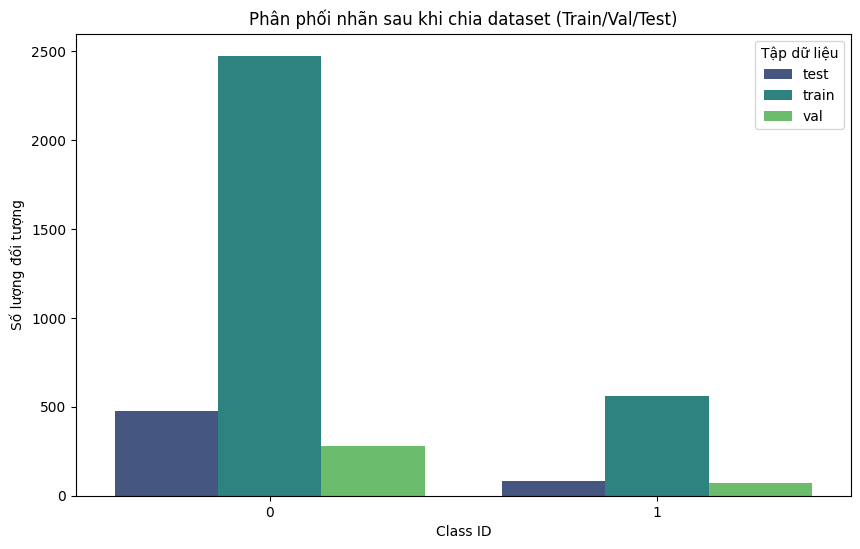

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thư mục chứa labels sau khi chia
base_labels_dir = "/kaggle/working/yolo_data_2classes/labels"
splits = ["train", "val", "test"]

# Khởi tạo danh sách để lưu dữ liệu
label_data = []

# Duyệt qua từng split
for split in splits:
    split_dir = os.path.join(base_labels_dir, split)
    if os.path.exists(split_dir):
        for file in os.listdir(split_dir):
            if file.endswith(".txt"):
                with open(os.path.join(split_dir, file), "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) > 0:
                            class_id = parts[0]  # YOLO format: class_id x y w h
                            label_data.append({"split": split, "class_id": class_id})

# Tạo DataFrame
labels_df = pd.DataFrame(label_data)

# Đếm số lượng mỗi class theo split
count_df = labels_df.groupby(["split", "class_id"]).size().reset_index(name="count")

print("--- PHÂN PHỐI NHÃN THEO SPLIT ---")
print(count_df)

# Vẽ biểu đồ phân phối nhãn
plt.figure(figsize=(10, 6))
sns.barplot(data=count_df, x="class_id", y="count", hue="split", palette="viridis")
plt.title("Phân phối nhãn sau khi chia dataset (Train/Val/Test)")
plt.xlabel("Class ID")
plt.ylabel("Số lượng đối tượng")
plt.legend(title="Tập dữ liệu")
plt.show()

## Tạo File Cấu Hình YAML

In [29]:
YOLO_BASE = '/kaggle/working/yolo_data_2classes'
data_yaml = f"""
path: {YOLO_BASE}
train: images/train
val: images/val
test: images/test

names:
  0: with_mask
  1: without_mask
"""

yaml_path = os.path.join(YOLO_BASE, "data.yaml")
with open(yaml_path, "w") as f:
    f.write(data_yaml)

print(open(yaml_path).read())


path: /kaggle/working/yolo_data_2classes
train: images/train
val: images/val
test: images/test

names:
  0: with_mask
  1: without_mask



## Train

In [30]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.6 MB/s eta 0:00:00
   ━━━━━

In [31]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt") 

model.train(
    data="/kaggle/working/yolo_data_2classes/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=10,

    # 🔥 Augmentation settings
    augment=True,     # bật toàn bộ augment mặc định
    fliplr=0.5,       # lật ngang (rất hiệu quả cho khuôn mặt)
    flipud=0.0,       # không lật dọc (không phù hợp cho mặt)
    degrees=5,        # xoay nhẹ ±5 độ
    scale=0.1,        # zoom ±10%
    shear=0.0,        # không cần kéo xiên cho mặt
    translate=0.05,   # tịnh tiến nhẹ
    hsv_h=0.015,      # thay đổi màu sắc nhẹ
    hsv_s=0.7,
    hsv_v=0.4,
    # mosaic=0.1,       # giảm mosaic vì bài toán là khuôn mặt
    mixup=0.0,        # không dùng mixup cho khuôn mặt    
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_data_2classes/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         83        351      0.923      0.834      0.907       0.62
             with_mask         75        278      0.939      0.832      0.912      0.646
          without_mask         30         73      0.907      0.836      0.901      0.595
Speed: 0.2ms preprocess, 16.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cfe21aed690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Testing

In [32]:
# Đánh giá trên tập Test
test_metrics = model.val(split='test') 

print(f"mAP50 (Test): {test_metrics.box.map50}")
print(f"mAP50-95 (Test): {test_metrics.box.map}")

Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3958.1±690.0 MB/s, size: 591.5 KB)
val: Scanning /kaggle/working/yolo_data_2classes/labels/test... 84 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 84/84 530.7it/s 0.2s
val: New cache created: /kaggle/working/yolo_data_2classes/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.5s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         84        562      0.883      0.733      0.822      0.517
             with_mask         80        478      0.954      0.788        0.9      0.566
          without_mask         32         84      0.813      0.679      0.745      0.468
Speed: 4.0ms preprocess, 24.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50 (Test): 0.8222888236719371
mAP50-95 (Test): 0.5169816841907731


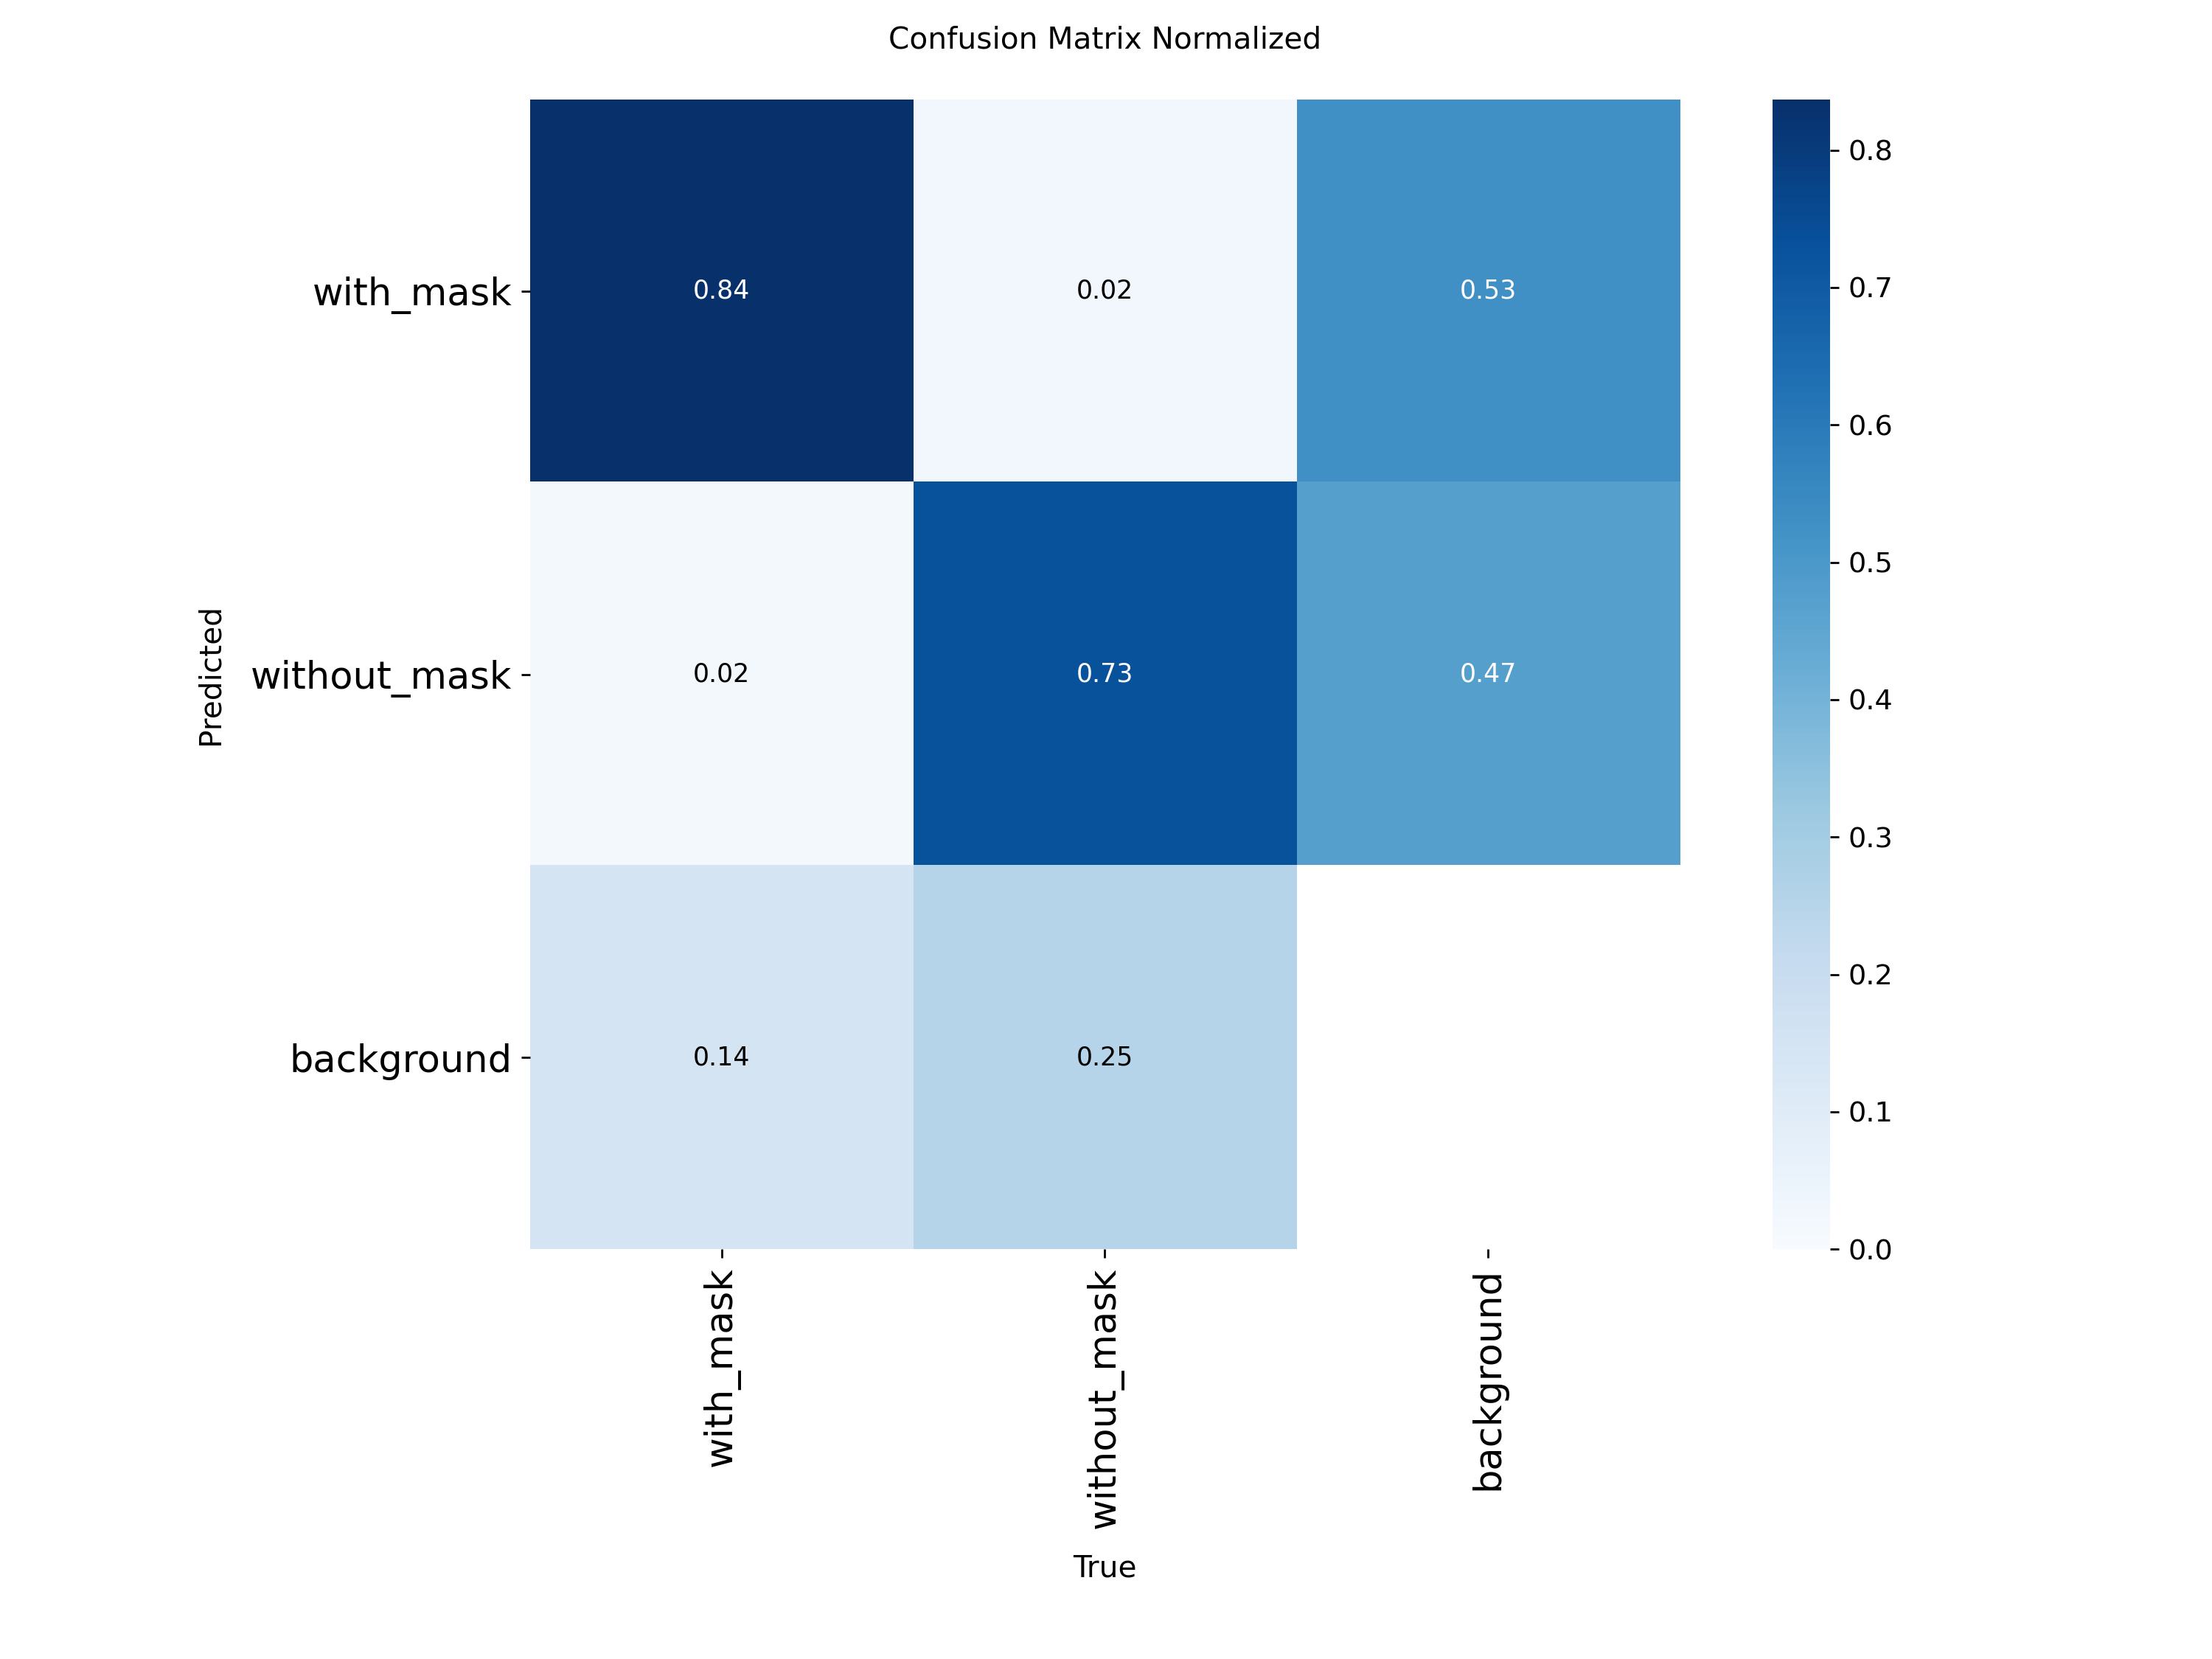

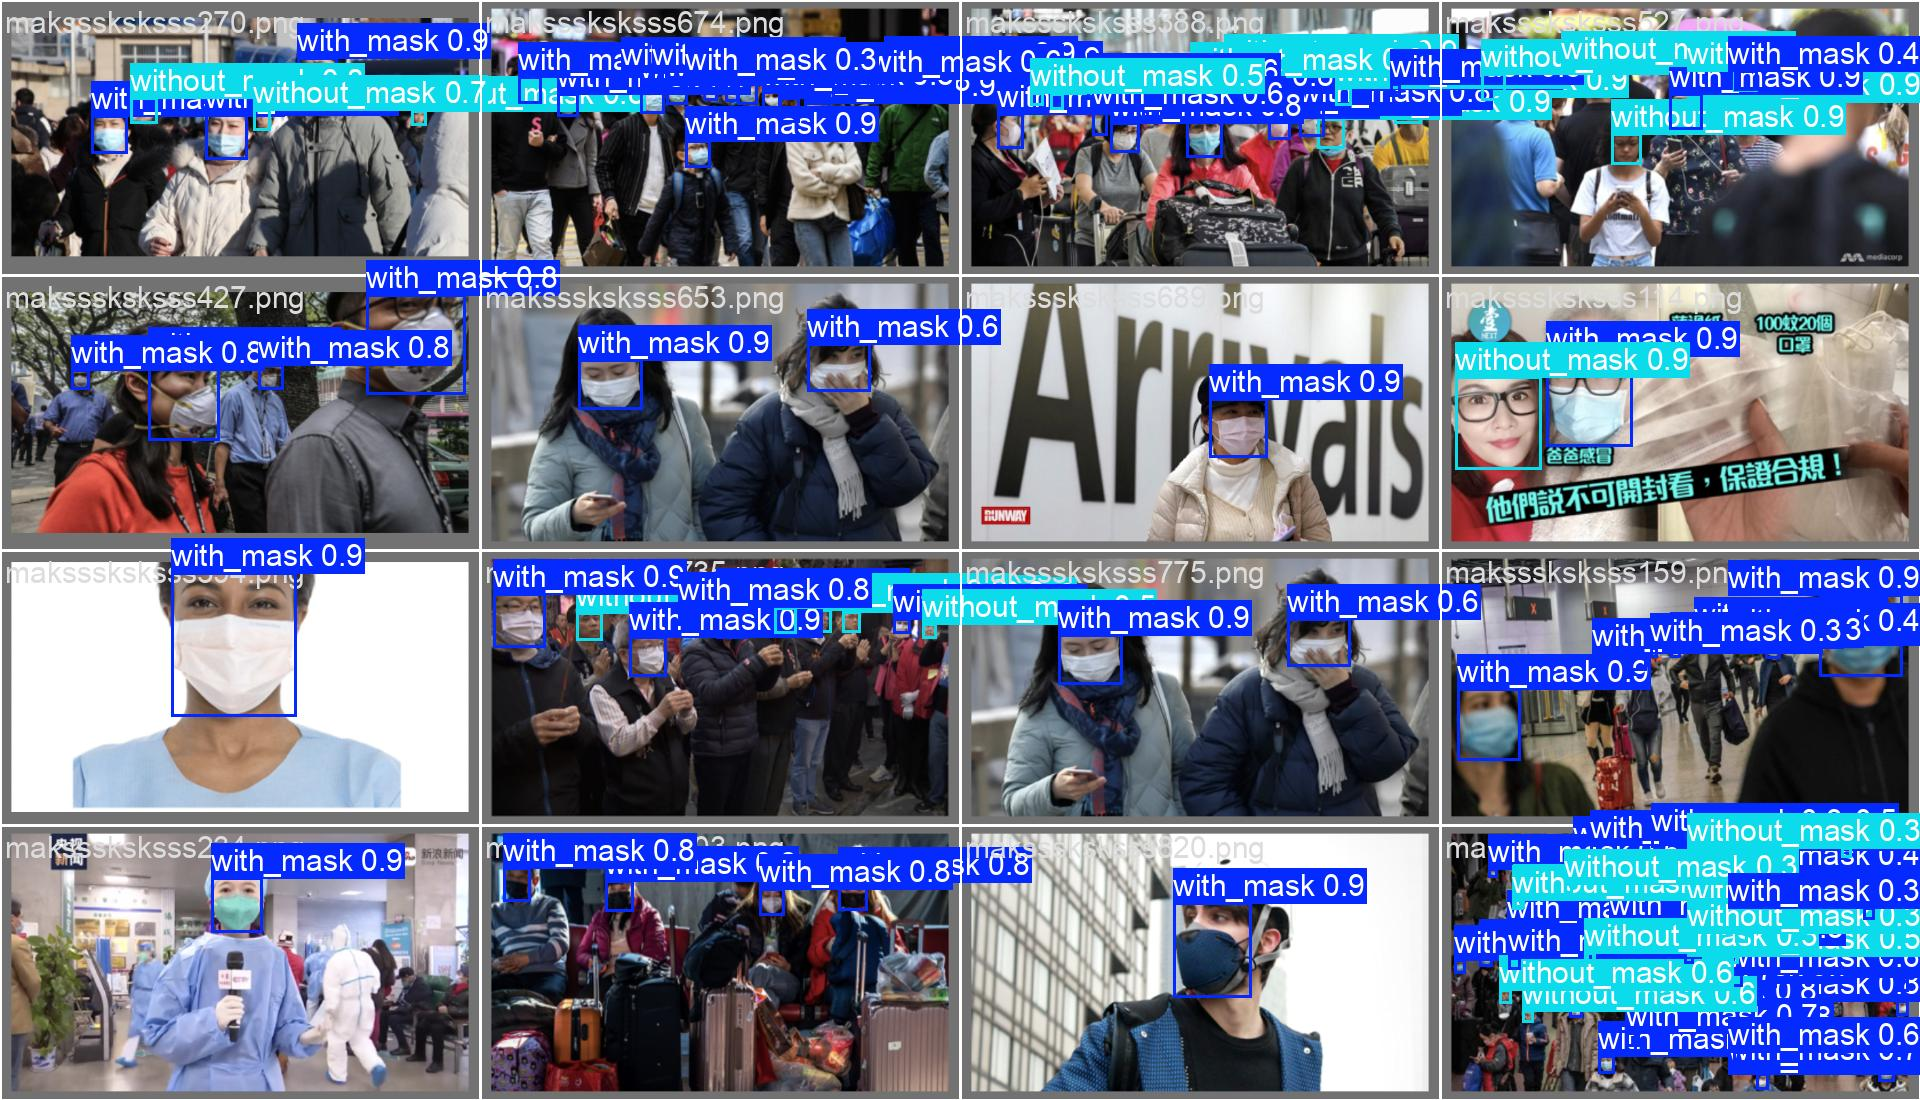

In [33]:
from IPython.display import Image, display

# Hiển thị Confusion Matrix (Ma trận nhầm lẫn)
# Giúp xem model có hay nhầm người đeo khẩu trang thành không đeo không
confusion_matrix_path = '/kaggle/working/runs/detect/val/confusion_matrix_normalized.png'
if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path, width=600))

# Hiển thị kết quả dự đoán trên một số ảnh Val
val_batch_path = '/kaggle/working/runs/detect/val/val_batch0_pred.jpg'
if os.path.exists(val_batch_path):
    display(Image(filename=val_batch_path, width=800))